## Imports

In [1]:
# imports

import pandas as pd
import numpy as np
import json
from pandas import json_normalize
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.spatial import distance_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import re
import glob
import matplotlib.cm as cm
import os
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=cm.Dark2.colors)
from TrackReconstruction_functions import *


## Functions

In [2]:
#-----GET VERTEX------
def get_vertex(part, eid):

    x_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_x.iloc[0]
    y_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_y.iloc[0]
    z_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_z.iloc[0]

    return x_vertex, y_vertex, z_vertex

In [3]:
def get_zshift(pressure):
    density = 5.987*pressure
    M = 1000/0.9
    det_size = 1000*np.cbrt((4 * M) / (np.pi * density))/2.0

    return det_size

z_shift = get_zshift(1)

In [4]:
def get_vertex_df(label_dir, five_full_df, zero_one_full_df, nodiff_full_df):
    five_lookup = five_full_df.set_index("event_id")
    zero_one_lookup = zero_one_full_df.set_index("event_id")
    nodiff_lookup = nodiff_full_df.set_index("event_id")
    rows = []
    vertex_dict = {}
    for file in os.listdir(label_dir):
        eid_str = file.split("_")[1]
        eid = int(eid_str)
        diffusion = file.split("_")[6]
        dims = file.split("_")[7][:2]
        dim_1, dim_2 = dims[0], dims[1]
        key = f"{eid_str}_{diffusion}"

        if diffusion == "5.0percent":
            lookup = five_lookup
        elif diffusion == "0.1percent":
            lookup = zero_one_lookup
        else:
            lookup = nodiff_lookup

        if eid not in lookup.index:
            print(f"No match for {eid}, skipping")
            continue

        row = lookup.loc[eid]
        true_vertex = row["vertex"]
        cos12_true = row["cos12_true"]
        raw = row["axis_limits"]
        if raw is None:
            print(f"No axis limits for event {eid}, skipping")
            continue
        limits = raw

        if dims not in limits:
            print(f"No limits for {dims} in event {eid}, skipping")
            continue

        xlim = limits[dims]["xlim"]
        ylim = limits[dims]["ylim"]

        if key not in vertex_dict:
            vertex_dict[key] = {
                "diffusion": diffusion,
                "x_true": None, "y_true": None, "z_true": None,
                f"{dim_1}_pred": [], f"{dim_2}_pred": [],
                "confidence": []
            }

        file_path = os.path.join(label_dir, file)
        with open(file_path, "r") as f:
            lines = f.readlines()

        best_line = None
        best_conf = -1
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 6:
                confidence = float(parts[-1])
            else:
                confidence = 1.0
            if confidence > best_conf:
                best_conf = confidence
                best_line = parts

        if best_line:
            cx, cy = float(best_line[1]), float(best_line[2])
            x_phys = cx * (xlim[1] - xlim[0]) + xlim[0]
            y_phys = (1 - cy) * (ylim[1] - ylim[0]) + ylim[0]

            rows.append({
                "event_id": eid,
                "diffusion": diffusion,
                "dim": dims,
                "x_true": true_vertex[0],
                "y_true": true_vertex[1],
                "z_true": true_vertex[2],
                f"{dim_1}_pred": x_phys,
                f"{dim_2}_pred": y_phys,
                "cos12_true": cos12_true,
                "confidence": best_conf
            })

    vertex_df = pd.DataFrame(rows)
    vertex_df.head()
    return vertex_df

In [5]:
def plot_predicted(eid, diffusion, vertex_df, z_shift):

    #getting hits info
    h5_file_key = int((int(eid)/120)-1)
    
    if diffusion == "nodiff":
        h5_diff = "nexus"
    else:
        h5_diff = f"{diffusion}_smear"
        
    h5_file_name = f"events_45_135_{h5_diff}_{h5_file_key}.h5"
    h5_dir = f"/mnt/d/events_45_135/simulated_data/1bar/{diffusion}"
    h5_path = os.path.join(h5_dir, h5_file_name)
    
    hits_df = pd.read_hdf(h5_path, "MC/hits")

    #getting row info
    vertex_row = vertex_df[(vertex_df["event_id"] == eid) & (vertex_df["diffusion"] == diffusion)]

    #getting dimensions
    dims_df = vertex_row[["x_pred", "y_pred", "z_pred"]]
    dims_df = dims_df.rename(columns={
        "x_pred": "x",
        "y_pred": "y",
        "z_pred": "z"})
    
    valid_dims = [
        col for col in dims_df.columns
        if dims_df[col].notna().any()
    ]
    
    dims = []
    for i in range(len(valid_dims)):
        for j in range(i+1, len(valid_dims)):
            dim1 = valid_dims[i]
            dim2 = valid_dims[j]
            dims.append(dim1+dim2)

    #plotting
    for i in dims:
        dim1 = i[0]
        dim2 = i[1]
        
        x_pred = vertex_row[f"{dim1}_pred"]
        y_pred = vertex_row[f"{dim2}_pred"]

        x_true = vertex_row[f"{dim1}_true"]
        y_true = vertex_row[f"{dim2}_true"]

        event_hits = hits_df[hits_df["event_id"] == eid]
        x_hits = event_hits[dim1]
        y_hits = event_hits[dim2]

        if (dim2 == "z") & (diffusion != "nodiff"):
            y_hits = y_hits - z_shift

        fig = plt.figure(figsize=(5,5))

        plt.scatter(x_hits, y_hits, alpha=0.02, s=10, c=event_hits.energy, cmap="Greys_r")
        plt.scatter(x_pred, y_pred, color="blue", s=20, label="Predicted Vertex")
        plt.scatter(x_true, y_true, color="red", s=20, label="True Vertex")

        plt.title(f"{dim1 + dim2} Projection Event {eid}")
        plt.legend()
        plt.xlabel(dim1)
        plt.ylabel(dim2)
        plt.grid(True, alpha=0.3, linewidth=0.5)

        plt.show()
        

In [6]:
def plot_hist_dist(vertex_df, title):
    distances = []
    
    for index, data in vertex_df.iterrows():
        pred_cols = {"x": data.get("x_pred"),
                     "y": data.get("y_pred"),
                     "z": data.get("z_pred")}
        
        true_cols = {"x": data.get("x_true"),
                     "y": data.get("y_true"),
                     "z": data.get("z_true")}

        valid_dims = [dim for dim, val in pred_cols.items()
                        if pd.notna(val)]

        dim_pairs = [
            (valid_dims[i], valid_dims[j])
            for i in range(len(valid_dims))
            for j in range(i+1, len(valid_dims))
        ]

        for dim1, dim2 in dim_pairs:
            xp = pred_cols[dim1]
            yp = pred_cols[dim2]

            xt = true_cols[dim1]
            yt = true_cols[dim2]

            dist = np.sqrt(((xt-xp)**2)+((yt-yp)**2))

            distances.append(dist)
            
    bins = int(np.ceil(np.log2(len(distances)) + 1))
    plt.figure(figsize=(5,5))
    plt.hist(distances, bins=bins)
    plt.title(title)
    plt.xlabel("Distance between predicted and true (2D)")
    plt.ylabel("Counts")

In [7]:
def percent_threshold(vertex_df, min_dist, max_dist):
    distances = []
    
    for index, data in vertex_df.iterrows():
        pred_cols = {"x": data.get("x_pred"),
                     "y": data.get("y_pred"),
                     "z": data.get("z_pred")}
        
        true_cols = {"x": data.get("x_true"),
                     "y": data.get("y_true"),
                     "z": data.get("z_true")}
        valid_dims = [dim for dim, val in pred_cols.items()
                        if pd.notna(val)]
        dim_pairs = [
            (valid_dims[i], valid_dims[j])
            for i in range(len(valid_dims))
            for j in range(i+1, len(valid_dims))
        ]
        for dim1, dim2 in dim_pairs:
            xp = pred_cols[dim1]
            yp = pred_cols[dim2]
            xt = true_cols[dim1]
            yt = true_cols[dim2]
            dist = np.sqrt((xt - xp)**2 + (yt - yp)**2)
            distances.append(dist)

    distances = np.array(distances)
    within_threshold = np.sum((distances <= max_dist) & (distances > min_dist))
    total_events = len(distances)
    percent = (within_threshold / total_events) * 100 if total_events > 0 else 0
    return percent

In [8]:
def percent_pie_chart(vertex_df, distance_ranges, title):
    percentages = []
    labels = []
    colors = plt.cm.Set3(np.linspace(0, 1, len(distance_ranges) + 1))
    for i, dist in enumerate(distance_ranges):
        if i==0:
            min_dist = 0
        else:
            min_dist = distance_ranges[i-1]

        percent = percent_threshold(vertex_df, min_dist, dist)
        label = f"{min_dist}-{dist} mm"
        percentages.append(percent)
        labels.append(label)

    greater = 100 - sum(percentages)
    percentages.append(greater)
    labels.append(f">{max(distance_ranges)} mm")

    fig, ax = plt.subplots(figsize=(6,6))
    wedges, texts, autotexts = ax.pie(
        percentages,
        startangle=90,
        counterclock=False,
        colors=colors,
        wedgeprops={"edgecolor": "black", "linewidth": 1},
        autopct=lambda pct: f"{pct:.1f}%" if pct >= 5 else "",       # automatically shows percent
        pctdistance=0.7,          # distance of percent text from center
        labeldistance=1.1 
    )
    
    ax.legend(
        wedges,
        labels,
        title="Distance from True Vertex",
        loc="upper right",
        bbox_to_anchor=(1, 0, 0.5, 1),
        fontsize=11
    )
            
    ax.set_title(title)
    plt.tight_layout()
    
    plt.show()

In [9]:
def angle_efficiency(vertex_df, title):
    vertex_df = vertex_df.groupby("event_id").agg({
            "x_pred": "mean",
            "y_pred": "mean",
            "z_pred": "mean",
            "cos12_true": "first",
            "x_true": "first",
            "y_true": "first",
            "z_true": "first"
        }).reset_index()
    vertex_df["dist"] = np.sqrt(
        (vertex_df["x_pred"] - vertex_df["x_true"])**2 +
        (vertex_df["y_pred"] - vertex_df["y_true"])**2 +
        (vertex_df["z_pred"] - vertex_df["z_true"])**2
    )
    true_angle = vertex_df["cos12_true"].clip(-1, 1)
    vertex_df["bin"] = pd.cut(x=true_angle, bins=15)
    total = vertex_df.groupby("bin", observed=True)["dist"].count()
    correct = vertex_df[vertex_df["dist"] <= 5].groupby("bin", observed=True)["dist"].count()
    result = pd.DataFrame({"total": total, "correct": correct}).fillna(0)
    print(result.head(15))
    result["efficiency"] = result["correct"] / result["total"]

    bin_midpoints = result.index.map(lambda b: b.mid)
    bin_lefts = np.array([b.left for b in result.index])
    
    plt.figure(figsize=(6,6))
    bin_width = bin_lefts[1] - bin_lefts[0]
    plt.bar(bin_lefts, result["efficiency"], color="rosybrown", width=bin_width, align="edge", edgecolor="maroon")
    plt.xlabel("cos12")
    plt.ylabel("Correct Predictions (dist < 5mm)")
    plt.title(title)
    plt.show()
    

## Creating Dataframes

In [10]:
nodiff_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/event_data/events_full_range_nodiff_1.jsonl", lines=True)

In [11]:
five_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/event_data/events_full_range_5.0percent_1.jsonl", lines=True)

In [12]:
zero_one_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/event_data/events_full_range_0.1percent_1.jsonl", lines=True)

In [13]:
nodiff_full_df.head()

,file,event_id,vertex,axis_limits,energies,vectors_true,cos12_true,vectors_reco,cos12_reco,vertex_1mm,...,cos12_2mm,vertex_3mm,vectors_3mm,cos12_3mm,vertex_4mm,vectors_4mm,cos12_4mm,vertex_5mm,vectors_5mm,cos12_5mm
0,events_full_range_nexus_149_7975749.h5,30000,"[2277.49609375, 581.3289794921875, 1946.750366...","{'xy': {'xlim': [2156.676062011719, 2571.82857...","[0.6562948822975151, 1.801699042320251]","[{'endpoint': [2277.871213916382, 581.93806974...",0.674890,"[{'endpoint': [2280.212646484375, 561.06323242...",0.391814,"[2278.3222930992406, 580.9854504446761, 1947.1...",...,0.483922,"[2276.5421892837626, 579.5633226484746, 1944.5...","[{'endpoint': [2280.212646484375, 561.06323242...",0.213880,"[2281.13766955602, 582.6136075139251, 1945.706...","[{'endpoint': [2280.212646484375, 561.06323242...",0.599928,"[2281.86018774851, 579.8077662131591, 1944.842...","[{'endpoint': [2280.212646484375, 561.06323242...",0.460307
1,events_full_range_nexus_149_7975749.h5,30001,"[437.98175048828125, 113.74400329589844, -1895...","{'xy': {'xlim': [-31.40203263759613, 766.81442...","[0.7035524249076841, 1.754457592964172]","[{'endpoint': [437.1174335329456, 113.91678268...",0.446982,"[{'endpoint': [423.4703674316406, 115.54029083...",0.033870,"[437.1738907531452, 113.82472091235853, -1895....",...,-0.107012,"[435.2160306820607, 114.79263823962589, -1895....","[{'endpoint': [438.71575927734375, 108.0336608...",0.126063,"[435.2944324135393, 110.78318386764711, -1895....","[{'endpoint': [423.4703674316406, 115.54029083...",-0.148800,"[442.5306823283901, 115.75185421354816, -1894....","[{'endpoint': [423.4703674316406, 115.54029083...",0.558095
2,events_full_range_nexus_149_7975749.h5,30002,"[-314.40911865234375, -2479.14501953125, 528.8...","{'xy': {'xlim': [-995.2144231796265, 3.1928281...","[0.745990276336669, 1.7120106220245361]","[{'endpoint': [-314.49658862282956, -2478.1782...",-0.038172,"[{'endpoint': [-322.2978515625, -2480.89819335...",0.021493,"[-313.6953387451307, -2479.826427864448, 528.7...",...,-0.058748,"[-317.2722429560114, -2479.223813598275, 529.7...","[{'endpoint': [-332.41583251953125, -2479.9990...",0.021328,"[-316.4204888080566, -2475.695191871962, 528.6...","[{'endpoint': [-313.8493347167969, -2454.26879...",-0.487150,"[-313.0554708369876, -2482.9023156764274, 531....","[{'endpoint': [-322.2978515625, -2480.89819335...",0.471850
3,events_full_range_nexus_149_7975749.h5,30003,"[-1832.31640625, 454.6137390136719, -731.60992...","{'xy': {'xlim': [-1853.4189697265624, -1500.10...","[0.7247740030288691, 1.7332178354263301]","[{'endpoint': [-1831.3590507532017, 454.543528...",0.460803,"[{'endpoint': [-1817.628662109375, 454.5359497...",0.314414,"[-1831.9331472875347, 455.103595578417, -732.3...",...,0.411083,"[-1832.0207125186992, 452.1224785899936, -729....","[{'endpoint': [-1828.7711181640625, 439.871002...",0.143717,"[-1833.5294037837268, 454.73489721331197, -735...","[{'endpoint': [-1828.7711181640625, 439.871002...",0.478352,"[-1836.0382978203672, 451.6454935347233, -733....","[{'endpoint': [-1828.7711181640625, 439.871002...",0.471297
4,events_full_range_nexus_149_7975749.h5,30004,"[1113.5433349609375, 1853.899658203125, -1770....","{'xy': {'xlim': [95.55943603515624, 1255.83948...","[0.6090482473373411, 1.8489525318145752]","[{'endpoint': [1113.4218350988813, 1852.915729...",-0.234450,"[{'endpoint': [1125.0521240234375, 1853.192504...",0.032586,"[1114.4167421242341, 1853.673886098063, -1771....",...,0.085380,"[1113.371880176304, 1853.0007466532427, -1773....","[{'endpoint': [1125.0521240234375, 1853.192504...",0.125975,"[1113.9029314371803, 1849.9471111237567, -1770...","[{'endpoint': [1125.0521240234375, 1853.192504...",-0.338837,"[1109.7346109021398, 1856.4970963753804, -1768...","[{'endpoint': [1125.0521240234375, 1853.192504...",0.351742


In [14]:
print(len(five_full_df))

114170


In [15]:
vertex_df_nodiff = get_vertex_df("/home/rei/NEXT/vertex_ML/yolo_data/detect/events_full_range_nodiff_t1_predict", five_full_df, zero_one_full_df, nodiff_full_df)
vertex_df_5percent = get_vertex_df("/home/rei/NEXT/vertex_ML/yolo_data/detect/events_full_range_5.0percent_t1_predict", five_full_df, zero_one_full_df, nodiff_full_df)
vertex_df_0_1percent = get_vertex_df("/home/rei/NEXT/vertex_ML/yolo_data/detect/events_full_range_0.1percent_t1_predict", five_full_df, zero_one_full_df, nodiff_full_df)

In [16]:
vertex_df_nodiff.head()

,event_id,diffusion,dim,x_true,y_true,z_true,x_pred,y_pred,cos12_true,confidence,z_pred
0,116252,nodiff,xy,-1837.005859,69.383156,2441.893066,-1835.418954,69.207197,0.217876,1.0,NaN
1,808,nodiff,xy,1477.541504,2583.629150,2314.990479,1477.541568,2583.139088,0.675115,1.0,NaN
2,167201,nodiff,xz,-2160.151123,1296.606323,-2033.989136,-2159.877594,NaN,0.422807,1.0,-2037.45706
3,126292,nodiff,xy,3.566936,1296.422119,-130.204834,-393.796557,1090.886425,0.551657,1.0,NaN
4,171469,nodiff,xy,-906.869507,1180.087280,1852.427490,-904.482891,1179.234159,0.744288,1.0,NaN


## Analysis

In [18]:
print(f"nodiff percent predicted: {(len(vertex_df_nodiff)/34303)*100}%")
print(f"5.0percent percent predicted: {(len(vertex_df_5percent)/34303)*100}%")
print(f"0.1percent percent predicted: {(len(vertex_df_0_1percent)/34303)*100}%")

nodiff percent predicted: 31.17220068215608%
5.0percent percent predicted: 18.90505203626505%
0.1percent percent predicted: 5.623414861673906%


                  total  correct
bin                             
(-1.0, -0.865]        5      0.0
(-0.865, -0.732]      4      2.0
(-0.732, -0.599]     10      1.0
(-0.599, -0.465]      9      7.0
(-0.465, -0.332]     11      8.0
(-0.332, -0.199]     21     11.0
(-0.199, -0.066]     16     10.0
(-0.066, 0.0672]     22     15.0
(0.0672, 0.2]        28     18.0
(0.2, 0.334]         35     26.0
(0.334, 0.467]       42     35.0
(0.467, 0.6]         30     26.0
(0.6, 0.733]         54     47.0
(0.733, 0.866]       43     37.0
(0.866, 0.999]       44     42.0


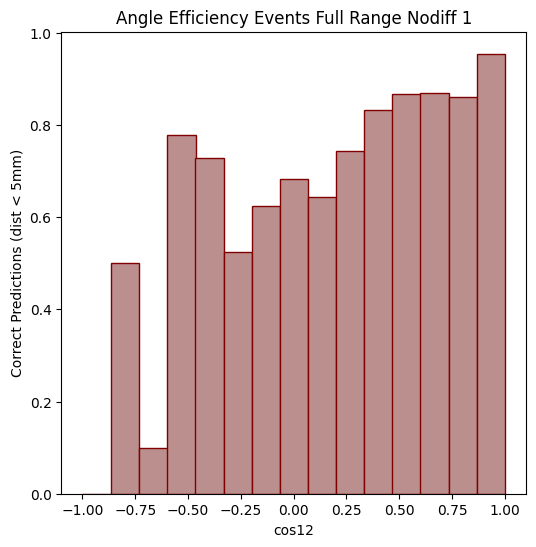

In [19]:
angle_efficiency(vertex_df_nodiff, "Angle Efficiency Events Full Range Nodiff 1")

                  total  correct
bin                             
(-1.0, -0.865]        5      0.0
(-0.865, -0.732]      3      0.0
(-0.732, -0.599]      4      0.0
(-0.599, -0.465]      3      0.0
(-0.465, -0.332]      6      0.0
(-0.332, -0.199]     10      0.0
(-0.199, -0.066]      9      2.0
(-0.066, 0.0672]      8      2.0
(0.0672, 0.2]         8      2.0
(0.2, 0.334]         13      3.0
(0.334, 0.467]       12      2.0
(0.467, 0.6]         17     10.0
(0.6, 0.733]         22      8.0
(0.733, 0.866]       14      7.0
(0.866, 0.999]       17      8.0


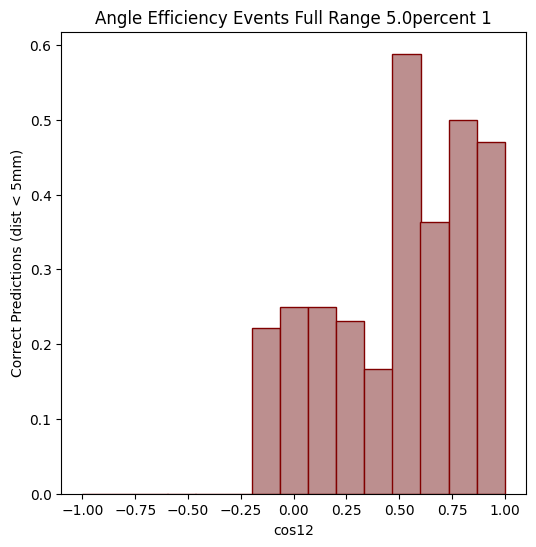

In [20]:
angle_efficiency(vertex_df_5percent, "Angle Efficiency Events Full Range 5.0percent 1")

                   total  correct
bin                              
(-0.998, -0.863]       0      0.0
(-0.863, -0.73]        0      0.0
(-0.73, -0.597]        0      0.0
(-0.597, -0.464]       0      0.0
(-0.464, -0.331]       1      0.0
(-0.331, -0.198]       2      0.0
(-0.198, -0.0648]      0      0.0
(-0.0648, 0.0683]      0      0.0
(0.0683, 0.201]        1      0.0
(0.201, 0.334]         0      0.0
(0.334, 0.467]         1      0.0
(0.467, 0.6]           2      0.0
(0.6, 0.733]           0      0.0
(0.733, 0.866]         2      1.0
(0.866, 0.999]         1      0.0


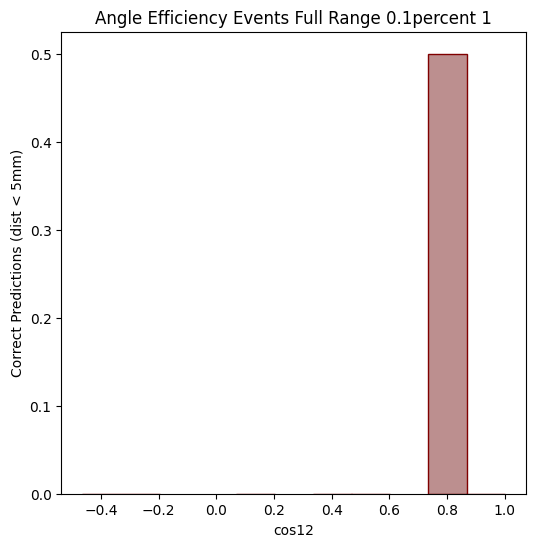

In [21]:
angle_efficiency(vertex_df_0_1percent, "Angle Efficiency Events Full Range 0.1percent 1")

In [27]:
%matplotlib widget
count = 0
for index, row in vertex_df_5k.iterrows():
    eid = row["event_id"]
    diffusion = row["diffusion"]
    plot_predicted(eid, diffusion, vertex_df_5k, z_shift)
    count += 1
    if count > 4:
        break
    

FileNotFoundError: File /mnt/d/events_45_135/simulated_data/1bar/nodiff/events_45_135_nexus_780.h5 does not exist

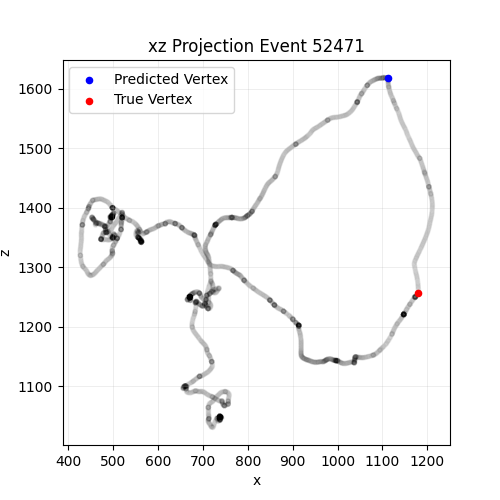

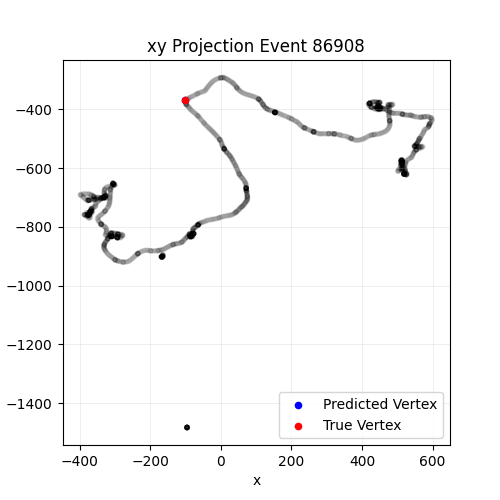

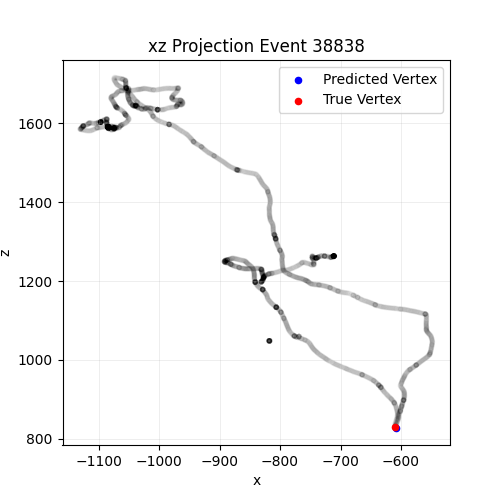

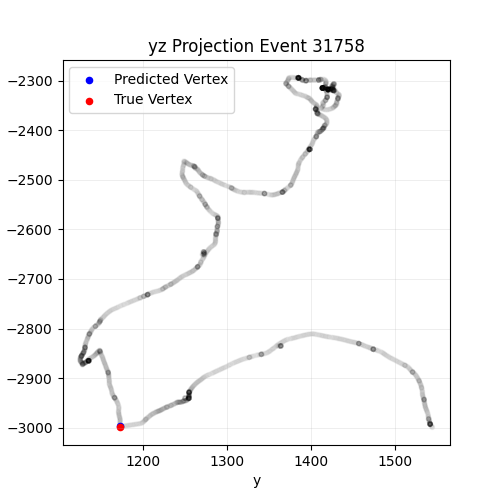

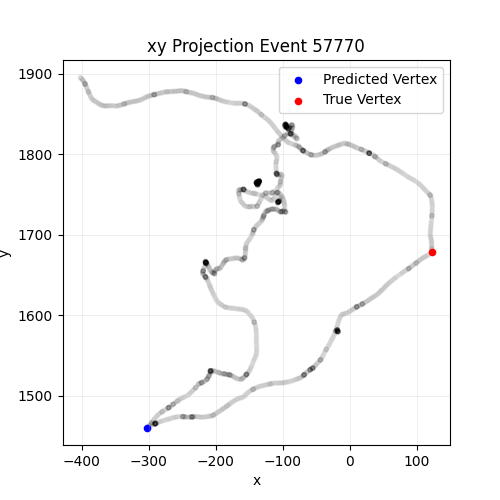

In [16]:
%matplotlib widget
count = 0
for index, row in vertex_df_30k.iterrows():
    eid = row["event_id"]
    diffusion = row["diffusion"]
    plot_predicted(eid, diffusion, vertex_df_30k, z_shift)
    count += 1
    if count > 4:
        break

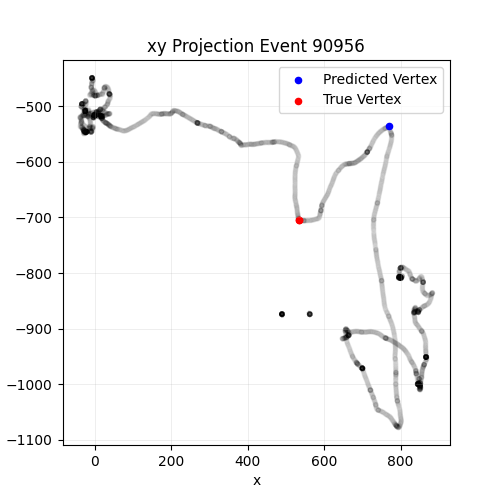

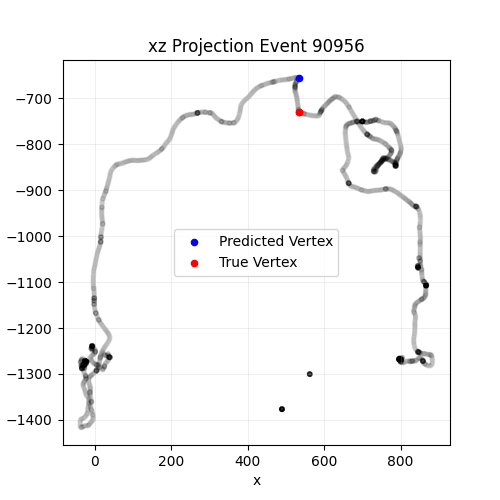

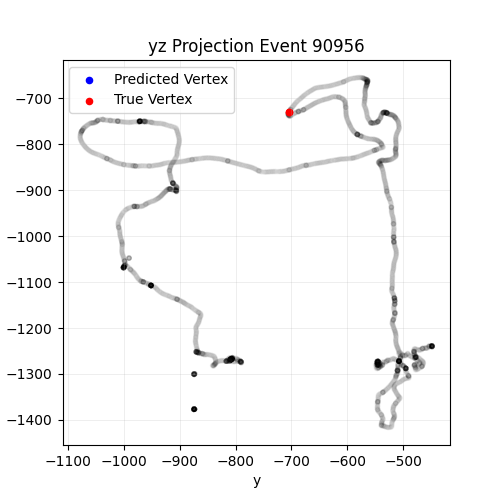

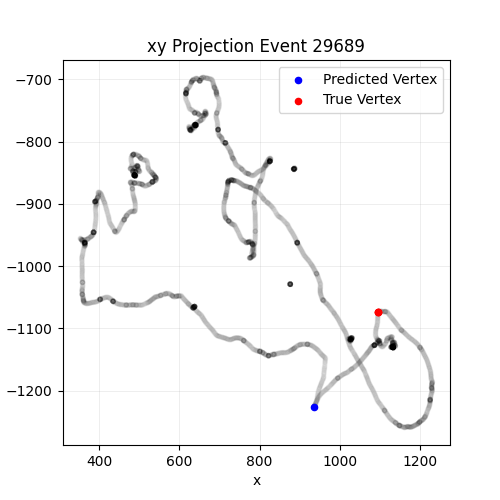

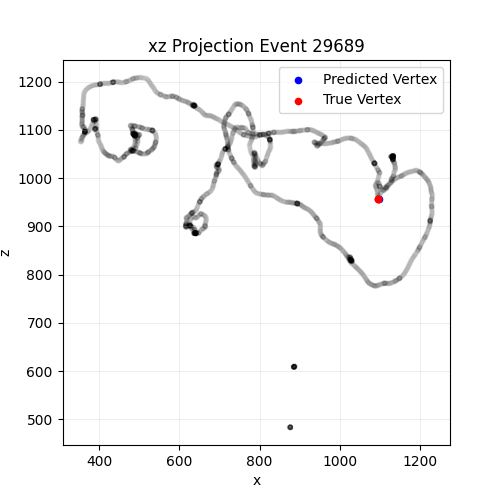

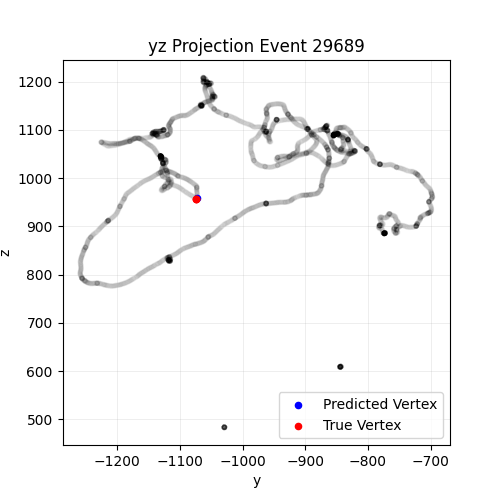

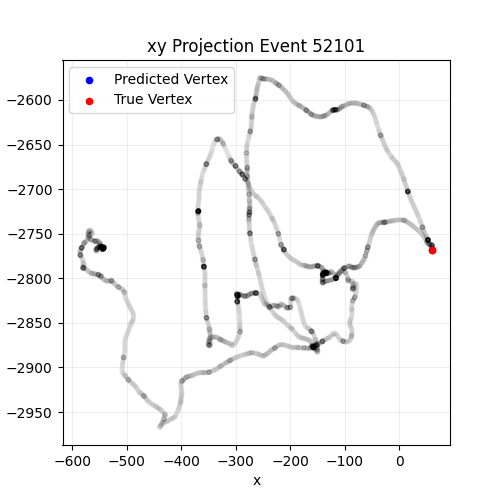

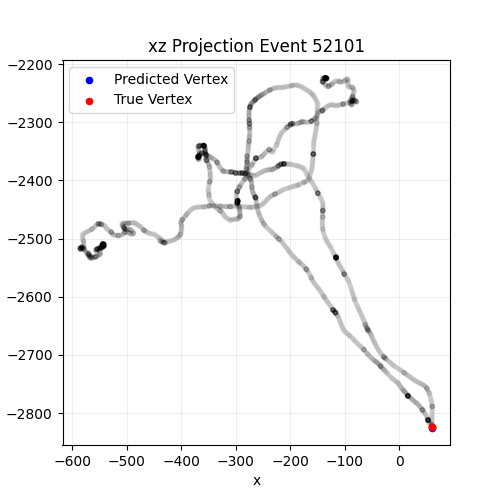

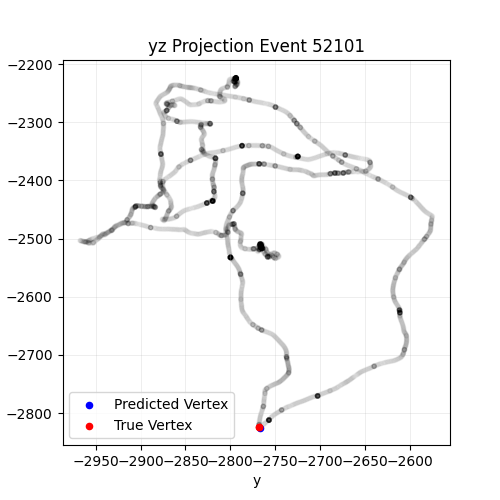

In [17]:
%matplotlib widget
count = 0
for index, row in vertex_df_nodiff.iterrows():
    eid = row["event_id"]
    diffusion = row["diffusion"]
    plot_predicted(eid, diffusion, vertex_df_nodiff, z_shift)
    count += 1
    if count > 2:
        break

/tmp/ipykernel_814/1133658432.py:34: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(5,5))


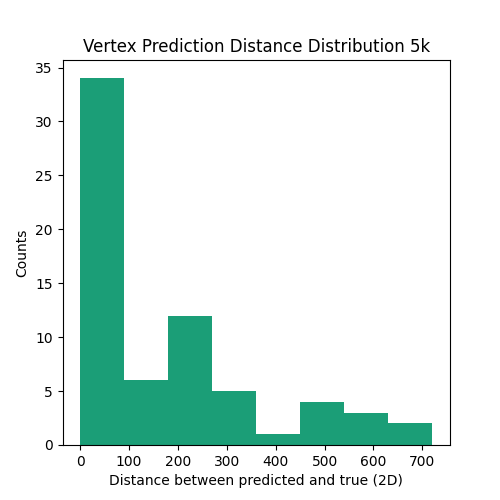

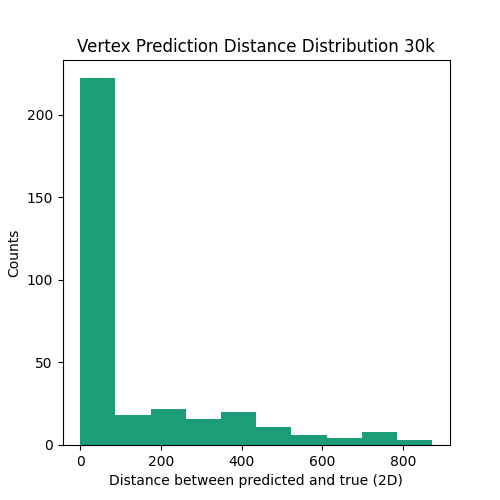

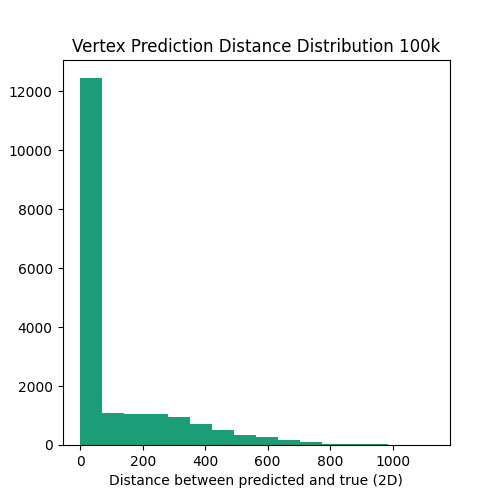

In [18]:
plot_hist_dist(vertex_df_5k, "Vertex Prediction Distance Distribution 5k")
plot_hist_dist(vertex_df_30k, "Vertex Prediction Distance Distribution 30k")
plot_hist_dist(vertex_df_nodiff, "Vertex Prediction Distance Distribution 100k")

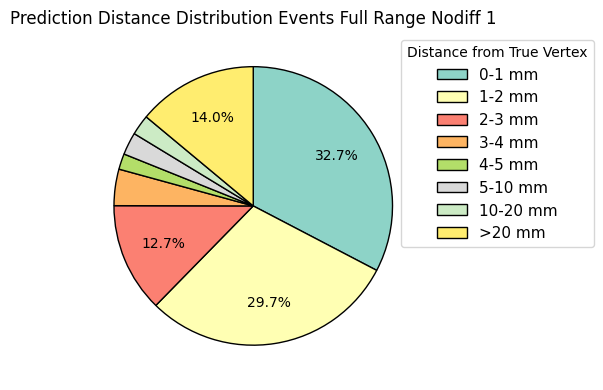

In [21]:
distance_ranges = [1, 2, 3, 4, 5, 10, 20]
percent_pie_chart(vertex_df_nodiff, distance_ranges, "Prediction Distance Distribution Events Full Range Nodiff 1")

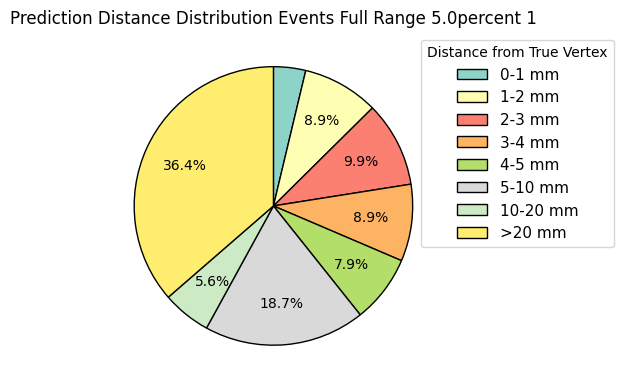

In [22]:
distance_ranges = [1, 2, 3, 4, 5, 10, 20]
percent_pie_chart(vertex_df_5percent, distance_ranges, "Prediction Distance Distribution Events Full Range 5.0percent 1")

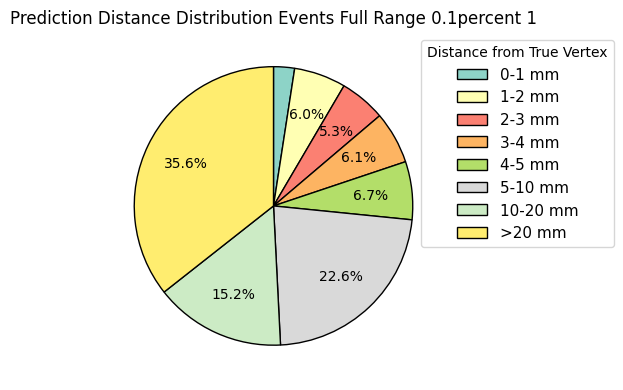

In [22]:
distance_ranges = [1, 2, 3, 4, 5, 10, 20]
percent_pie_chart(vertex_df_0_1percent, distance_ranges, "Prediction Distance Distribution Events Full Range 0.1percent 1")

In [23]:
import gc

for name in list(globals()):
    if isinstance(globals()[name], pd.DataFrame):
        del globals()[name]

gc.collect()

11467

In [20]:
plt.close("all")

In [9]:
test_file = "/mnt/d/events_full_range/simulated_data/1bar/5.0percent/events_full_range_5.0percent_smear_9.h5"
df = pd.read_hdf(test_file, "MC/hits")
df.head()
test_label_file = "event_1200_events_full_range_1_5.0percent_xy.txt"
with open(test_label_file, "r") as f:
    

SyntaxError: incomplete input (3215136999.py, line 6)

In [4]:
df = pd.read_hdf("/home/rei/events_full_range_nexus_0.h5", "MC/hits")
df.head()

,event_id,x,y,z,time,energy,label,particle_id,hit_id
0,120,2764.349365,-121.459480,-865.729736,0.003494,0.000204,GAS,2,0
1,120,2764.431641,-122.274460,-865.156616,0.006988,0.000171,GAS,2,1
2,120,2764.542236,-123.082596,-864.578125,0.010483,0.000881,GAS,2,2
3,120,2764.674561,-123.873100,-863.980225,0.013978,0.000465,GAS,2,3
4,120,2764.825684,-124.662582,-863.385559,0.017473,0.000063,GAS,2,4
